we compare the 3 possibilistic bayesian methods with the default params first with the normal bayesian method and the 1/n method on the kenneth french db with the new path to retain correct. 

this is then compared using sharpe, rolling sharpe, log likelihood, and mahalnobis

then we run that thing on the 2 sim ds, and create 1-2 ds of our own to see what works

after that, we can play with other gamma and eta on the possibilistic version.


In [1]:
import numpy as np
import pickle
import pandas as pd
from data_input import load_excess_returns_from_kenneth_french_path, prepare_returns
from pathlib import Path
from portfolio_evaluation_functions import calculate_sharpe_ratio, rolling_sharpe_ratio
from distribution_evalutation_func import mahalanobis_distance_series, multivariate_log_likelihood_series, average_log_likelihood
from alternative_investment_rules import rolling_window_weights, jorion_bayes_stein_strategy
import bayesian_averaging

we set the initial paths to the kenneth french db. as the pruning reduces the size and complexity of the problem, we can take the unconstrained dataset for comparison over a longer period.

In [2]:
import importlib
import possibilistic_bayesian

importlib.reload(possibilistic_bayesian)

<module 'possibilistic_bayesian' from '/Users/jaini/possibilistic-portfolio-optimisation-py/dev/src/possibilistic_bayesian.py'>

In [3]:
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()

DATA_PATH = BASE_DIR / "../../datasets/10_Industry_Portfolios_Daily.csv"
RISK_FREE_RATE_PATH = BASE_DIR / "../../datasets/F-F_Research_Data_Factors_daily.csv"

df = pd.read_csv

df_excess_returns = load_excess_returns_from_kenneth_french_path(portfolios_path=DATA_PATH, risk_free_path= RISK_FREE_RATE_PATH, start_date="2000-01-01")
df_excess_returns_prepared = prepare_returns(df_excess_returns, drop_cols=("Date", "RF"))



In [4]:
#we get the mu_hat and sigma hat under each strategy, as well as the weights under each strategy
returns_df = df_excess_returns_prepared [:3101]
burn_in = 100
periods_until_investment = 0

In [5]:


bayesian_mus_sigmas, bayesian_weights = bayesian_averaging.run_core(returns_df=returns_df, burn_in = burn_in, periods_until_investment=periods_until_investment, max_models=200)
rollings_window_mus_sigmas, rolling_window_weights_df = rolling_window_weights(returns_df=df_excess_returns_prepared, window=100, burn_in = burn_in, periods_until_investment=periods_until_investment)
jorion_bayes_mus_sigma, jorion_bayes_weights = jorion_bayes_stein_strategy (returns_df=returns_df, burn_in=burn_in, periods_until_investment=periods_until_investment)


Processing time step 100 / 3101...
Processing time step 200 / 3101...
Processing time step 300 / 3101...
Processing time step 400 / 3101...
Processing time step 500 / 3101...
Processing time step 600 / 3101...
Processing time step 700 / 3101...
Processing time step 800 / 3101...
Processing time step 900 / 3101...
Processing time step 1000 / 3101...
Processing time step 1100 / 3101...
Processing time step 1200 / 3101...
Processing time step 1300 / 3101...
Processing time step 1400 / 3101...
Processing time step 1500 / 3101...
Processing time step 1600 / 3101...
Processing time step 1700 / 3101...
Processing time step 1800 / 3101...
Processing time step 1900 / 3101...
Processing time step 2000 / 3101...
Processing time step 2100 / 3101...
Processing time step 2200 / 3101...
Processing time step 2300 / 3101...
Processing time step 2400 / 3101...
Processing time step 2500 / 3101...
Processing time step 2600 / 3101...
Processing time step 2700 / 3101...
Processing time step 2800 / 3101...
P

In [9]:
sharpe_bayesian_original = calculate_sharpe_ratio(returns_df, bayesian_weights, scaling_factor=252)
sharpe_bayesian_original

0.08910896602922035

In [55]:
sharpe_jor_original = calculate_sharpe_ratio(returns_df, jorion_bayes_weights)
sharpe_jor_original

0.0654270615103965

In [56]:
sharpe_rolling = calculate_sharpe_ratio(returns_df, rolling_window_weights)
sharpe_rolling

KeyError: '[12211, 12212, 12213, 12214, 12215, 12216, 12217, 12218, 12219, 12220, 12221, 12222, 12223, 12224, 12225, 12226, 12227, 12228, 12229, 12230, 12231, 12232, 12233, 12234, 12235, 12236, 12237, 12238, 12239, 12240, 12241, 12242, 12243, 12244, 12245, 12246, 12247, 12248, 12249, 12250, 12251, 12252, 12253, 12254, 12255, 12256, 12257, 12258, 12259, 12260, 12261, 12262, 12263, 12264, 12265, 12266, 12267, 12268, 12269, 12270, 12271, 12272, 12273, 12274, 12275, 12276, 12277, 12278, 12279, 12280, 12281, 12282, 12283, 12284, 12285, 12286, 12287, 12288, 12289, 12290, 12291, 12292, 12293, 12294, 12295, 12296, 12297, 12298, 12299, 12300, 12301, 12302, 12303, 12304, 12305, 12306, 12307, 12308, 12309, 12310, 12311, 12312, 12313, 12314, 12315, 12316, 12317, 12318, 12319, 12320, 12321, 12322, 12323, 12324, 12325, 12326, 12327, 12328, 12329, 12330, 12331, 12332, 12333, 12334, 12335, 12336, 12337, 12338, 12339, 12340, 12341, 12342, 12343, 12344, 12345, 12346, 12347, 12348, 12349, 12350, 12351, 1

In [6]:
# mu_sigma_masked, weights_masked, mu_sigma_power, weights_power, mu_sigma_exponential, weights_exponential = possibilistic_bayesian.run_core(returns_df = df_excess_returns_prepared, burn_in = burn_in, periods_until_investment=periods_until_investment, max_models = 500)


In [7]:
# results = {
#     "masked": {
#         "mu_sigma": mu_sigma_masked,
#         "weights": weights_masked,
#     },
#     "power": {
#         "mu_sigma": mu_sigma_power,
#         "weights": weights_power,
#     },
#     "exponential": {
#         "mu_sigma": mu_sigma_exponential,
#         "weights": weights_exponential,
#     },
# }

# with open("results.pkl", "wb") as f:
#     pickle.dump(results, f)

NameError: name 'mu_sigma_masked' is not defined

In [14]:
file_path = 'results.pkl'

with open(file_path, 'rb') as file:
    data = pickle.load(file)

for keys, values in data.items():
    print(f"{keys}: {list(values.keys())}")


masked: ['mu_sigma', 'weights']
power: ['mu_sigma', 'weights']
exponential: ['mu_sigma', 'weights']


In [15]:

# ── Build a unified strategy registry ────────────────────────────────────────
# Each entry: {"weights": pd.DataFrame, "mu_sigma": dict with mu_hat/sigma_hat}
import os

strategies = {
    "Bayesian Averaging":  {"weights": bayesian_weights,      "mu_sigma": bayesian_mus_sigmas},
    "Rolling Window":      {"weights": rolling_window_weights, "mu_sigma": rollings_window_mus_sigmas},
    "Jorion Bayes-Stein":  {"weights": jorion_bayes_weights,   "mu_sigma": jorion_bayes_mus_sigma},
}

# Add possibilistic strategies from pkl if available
_pkl = "results.pkl"
if os.path.exists(_pkl):
    with open(_pkl, "rb") as _f:
        _poss = pickle.load(_f)
    _name_map = {
        "masked":      "Possibilistic (Masked)",
        "power":       "Possibilistic (Power)",
        "exponential": "Possibilistic (Exponential)",
    }
    for _key, _label in _name_map.items():
        if _key in _poss:
            strategies[_label] = {
                "weights":  _poss[_key]["weights"],
                "mu_sigma": _poss[_key]["mu_sigma"],
            }
    print(f"Loaded possibilistic strategies from {_pkl}.")
else:
    print("results.pkl not found – only non-possibilistic strategies loaded.")

print("Strategies:", list(strategies.keys()))


Loaded possibilistic strategies from results.pkl.
Strategies: ['Bayesian Averaging', 'Rolling Window', 'Jorion Bayes-Stein', 'Possibilistic (Masked)', 'Possibilistic (Power)', 'Possibilistic (Exponential)']


In [16]:

# ── Sharpe ratios ─────────────────────────────────────────────────────────────
SCALE = 252  # trading days → annualised

rows = []
for name, strat in strategies.items():
    sharpe_daily = calculate_sharpe_ratio(returns_df, strat["weights"])
    sharpe_ann   = calculate_sharpe_ratio(returns_df, strat["weights"], scaling_factor=SCALE)
    rows.append({"Strategy": name, "Sharpe (daily)": sharpe_daily, "Sharpe (annualised)": sharpe_ann})

sharpe_df = pd.DataFrame(rows).set_index("Strategy").round(4)
print(sharpe_df.to_string())
sharpe_df


                             Sharpe (daily)  Sharpe (annualised)
Strategy                                                        
Bayesian Averaging                   0.1502               2.3849
Rolling Window                       0.0876               1.3907
Jorion Bayes-Stein                   0.0620               0.9841
Possibilistic (Masked)               0.0375               0.5960
Possibilistic (Power)                0.0349               0.5542
Possibilistic (Exponential)          0.0375               0.5947


,Sharpe (daily),Sharpe (annualised)
Strategy,,
Bayesian Averaging,0.1502,2.3849
Rolling Window,0.0876,1.3907
Jorion Bayes-Stein,0.0620,0.9841
Possibilistic (Masked),0.0375,0.5960
Possibilistic (Power),0.0349,0.5542
Possibilistic (Exponential),0.0375,0.5947


Saved rolling_sharpe_ratios.csv
       Bayesian Averaging  Rolling Window  Jorion Bayes-Stein  \
count          14255.0000      14255.0000          14255.0000   
mean               2.3901          1.0812              0.7983   
std                2.7801          2.4497              2.6696   
min               -4.6280         -5.1874             -8.7042   
25%                0.2309         -0.6655             -0.7652   
50%                2.2075          0.9618              0.6500   
75%                4.6900          2.5132              2.2761   
max               10.3684         11.5037             13.6292   

       Possibilistic (Masked)  Possibilistic (Power)  \
count              14255.0000             14255.0000   
mean                   0.9428                 0.9353   
std                    2.1204                 2.1509   
min                   -6.3609                -6.3485   
25%                   -0.5236                -0.5140   
50%                    0.8148                 

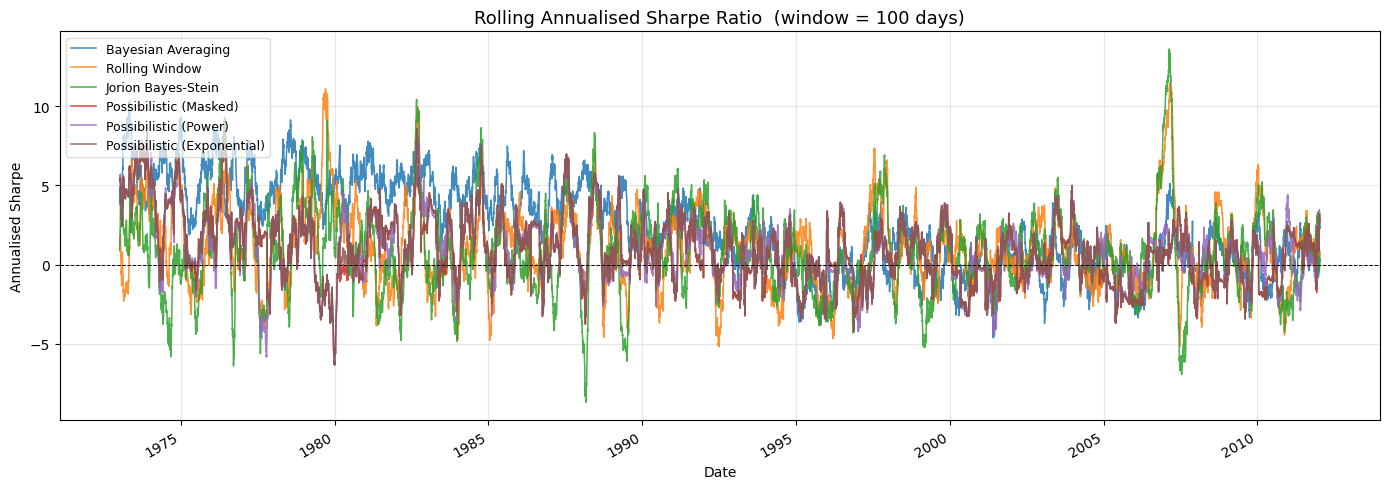

In [ ]:

# ── Rolling Sharpe (window = 100) ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

WINDOW = 100

rolling_sharpes = {}
for name, strat in strategies.items():
    rolling_sharpes[name] = rolling_sharpe_ratio(
        returns_df, strat["weights"], window=WINDOW, scaling_factor=SCALE
    )

rolling_sharpe_df = pd.DataFrame(rolling_sharpes)
rolling_sharpe_df.index.name = "Date"
rolling_sharpe_df.to_csv("rolling_sharpe_ratios.csv")
print("Saved rolling_sharpe_ratios.csv")
print(rolling_sharpe_df.describe().round(4))

# Plot
n_strats = len(rolling_sharpes)
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 5))
for (name, series), color in zip(rolling_sharpes.items(), colors):
    ax.plot(series.index, series.values, label=name, color=color, linewidth=1.1, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_title(f"Rolling Annualised Sharpe Ratio  (window = {WINDOW} days)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Sharpe")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
ax.legend(loc="upper left", fontsize=9, framealpha=0.7)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig("rolling_sharpe_plot.png", dpi=150)
plt.show()


In [30]:
with open("results.pkl", "rb") as f:
    data = pickle.load(f)

weights_masked = data["masked"]["weights"]                                                                              
print(weights_masked.describe())
print(weights_masked.abs().max().max())  # worst single weight across all assets/times                                  
                                                                                                                          

              NoDur         Durbl         Manuf         Enrgy         HiTec  \
count  14354.000000  14354.000000  14354.000000  14354.000000  14354.000000   
mean      11.273916     -0.409062      8.292547      7.727694     12.290582   
std       53.523472     50.966032     59.406594     52.969762     52.245016   
min     -714.007527   -608.679226   -647.111255   -586.894991   -491.319123   
25%       -1.533677     -6.823379     -5.134925     -0.410778     -1.116910   
50%       11.365842      2.392224     12.103136      6.495516     10.934132   
75%       23.470411      8.745221     29.840536     12.909032     21.428454   
max      460.384836    516.176428    461.675499    649.721881    809.360520   

              Telcm         Shops         Hlth          Utils         Other  \
count  14354.000000  14354.000000  14354.000000  14354.000000  14354.000000   
mean       3.121341     15.465701      7.711264      1.754076      7.730027   
std       55.852902     54.922682     62.918384    

In [31]:
print(bayesian_weights.abs().max().max())                                                                               
print(jorion_bayes_weights.abs().max().max())
print(rolling_window_weights.abs().max().max()) 

467.11838407163543
8535.167953366665
25526.204739756387


─── Average Log-Likelihoods ───
                             Avg Log-Likelihood
Strategy                                       
Bayesian Averaging                      39.4301
Rolling Window                          43.7980
Jorion Bayes-Stein                      43.8128
Possibilistic (Masked)                  38.2229
Possibilistic (Power)                   38.8819
Possibilistic (Exponential)             38.2434


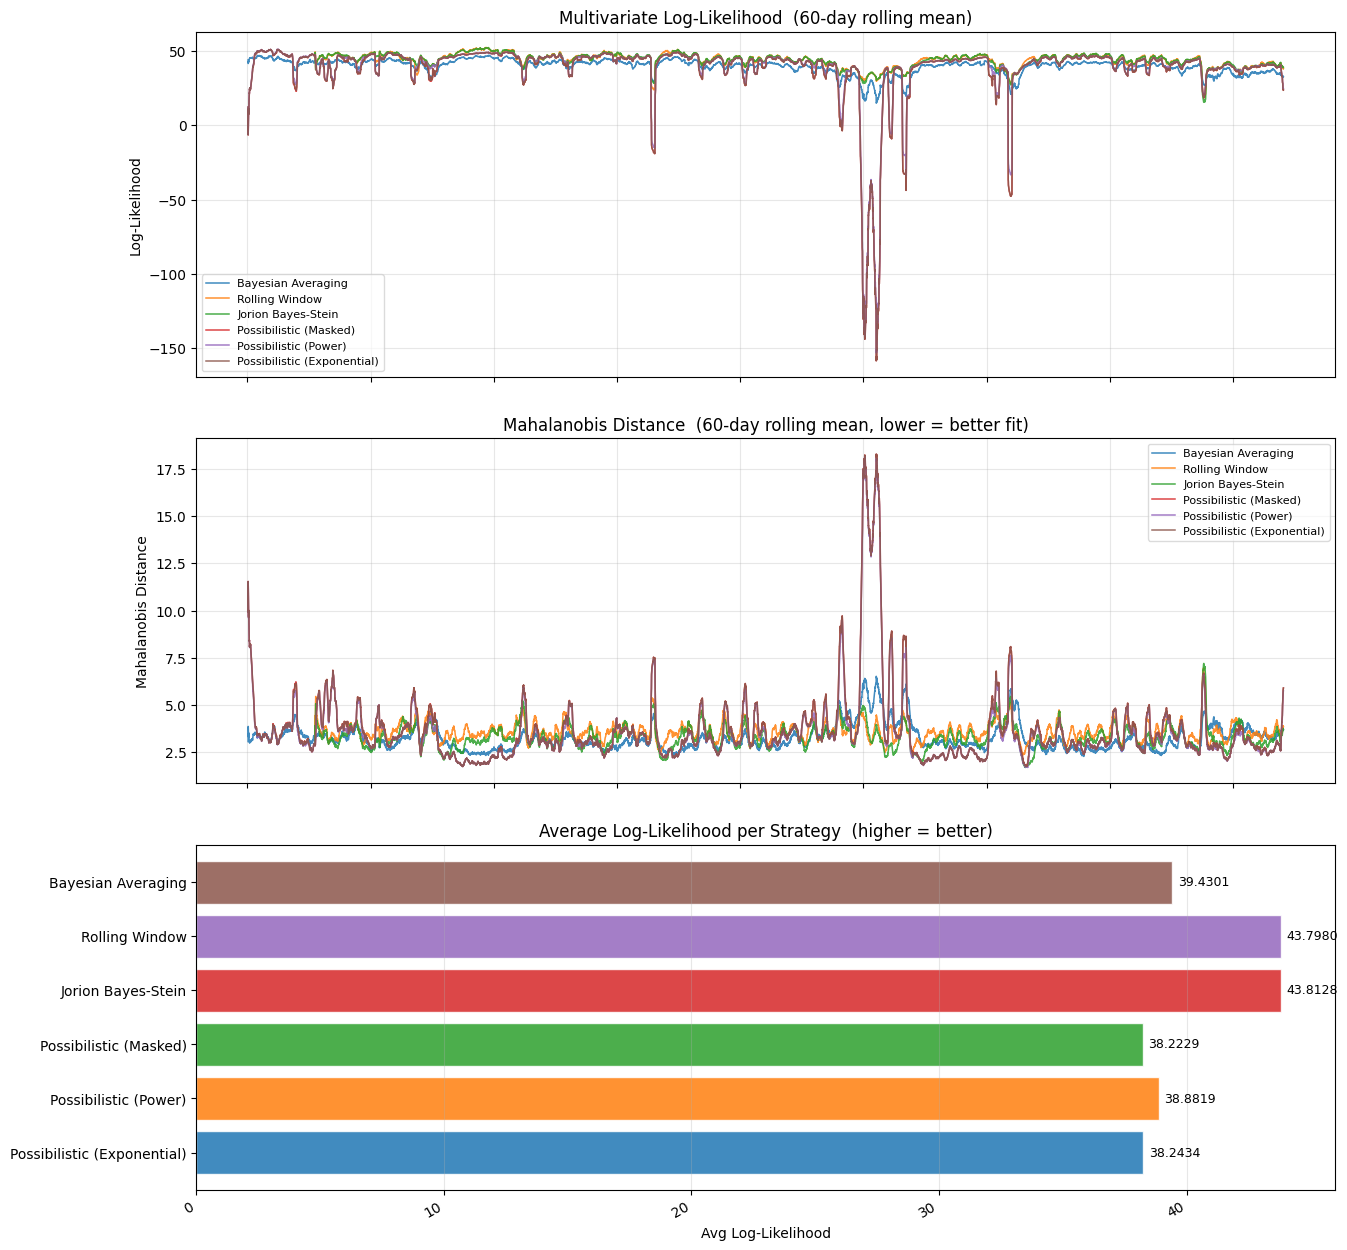

,Avg Log-Likelihood
Strategy,
Bayesian Averaging,39.4301
Rolling Window,43.7980
Jorion Bayes-Stein,43.8128
Possibilistic (Masked),38.2229
Possibilistic (Power),38.8819
Possibilistic (Exponential),38.2434


In [29]:

# ── Distribution evaluation: log-likelihood, Mahalanobis, avg log-likelihood ──
from distribution_evalutation_func import (
    mahalanobis_distance_series,
    multivariate_log_likelihood_series,
    average_log_likelihood,
)

ll_series    = {}
mah_series   = {}
avg_ll_rows  = []

for name, strat in strategies.items():
    ms = strat["mu_sigma"]
    ll_series[name]  = multivariate_log_likelihood_series(returns_df, ms, lag=1)
    mah_series[name] = mahalanobis_distance_series(returns_df, ms, lag=1)
    avg_ll           = average_log_likelihood(returns_df, ms, lag=1)
    avg_ll_rows.append({"Strategy": name, "Avg Log-Likelihood": avg_ll})

avg_ll_df = pd.DataFrame(avg_ll_rows).set_index("Strategy").round(4)
print("─── Average Log-Likelihoods ───")
print(avg_ll_df.to_string())

ll_df  = pd.DataFrame(ll_series);  ll_df.index.name  = "Date"
mah_df = pd.DataFrame(mah_series); mah_df.index.name = "Date"

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)

# 1. Log-likelihood series (smoothed with 60-day rolling mean for readability)
ax = axes[0]
for (name, series), color in zip(ll_series.items(), colors):
    smoothed = series.rolling(60, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed.values, label=name, color=color, linewidth=1.1, alpha=0.85)
ax.set_title("Multivariate Log-Likelihood  (60-day rolling mean)", fontsize=12)
ax.set_ylabel("Log-Likelihood")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
ax.legend(fontsize=8, framealpha=0.7)
ax.grid(alpha=0.3)

# 2. Mahalanobis distance series (smoothed)
ax = axes[1]
for (name, series), color in zip(mah_series.items(), colors):
    smoothed = series.rolling(60, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed.values, label=name, color=color, linewidth=1.1, alpha=0.85)
ax.set_title("Mahalanobis Distance  (60-day rolling mean, lower = better fit)", fontsize=12)
ax.set_ylabel("Mahalanobis Distance")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
ax.legend(fontsize=8, framealpha=0.7)
ax.grid(alpha=0.3)

# 3. Average log-likelihood bar chart
ax = axes[2]
bars = ax.barh(
    avg_ll_df.index[::-1],
    avg_ll_df["Avg Log-Likelihood"].values[::-1],
    color=colors[: len(avg_ll_df)],
    alpha=0.85,
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_title("Average Log-Likelihood per Strategy  (higher = better)", fontsize=12)
ax.set_xlabel("Avg Log-Likelihood")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout(pad=2.5)
plt.savefig("distribution_evaluation_plot.png", dpi=150)
plt.show()

avg_ll_df


In [ ]:
bayesian_mu = bayesian_mus_sigmas["mu_hat"]                                                                             
possibilistic_mu = data["masked"]["mu_sigma"]["mu_hat"]

bayesian_mu = bayesian_mus_sigmas["mu_hat"]                                                                             
possibilistic_mu = data["masked"]["mu_sigma"]["mu_hat"]

print("Bayesian |mu| mean:", np.nanmean(np.abs(bayesian_mu)))                                                           
print("Possibilistic |mu| mean:", np.nanmean(np.abs(possibilistic_mu)))
                                                                                                                        
# also check correlation of the two mu series — are they pointing in the same direction?                                
mask = ~(np.isnan(bayesian_mu).any(axis=1) | np.isnan(possibilistic_mu).any(axis=1))
corr = np.corrcoef(bayesian_mu[mask].flatten(), possibilistic_mu[mask].flatten())[0, 1]                                 
print("Correlation between mu estimates:", corr)  

Bayesian |mu| mean: 0.0028584846904321807
Possibilistic |mu| mean: 0.0010418323330374229
Correlation between mu estimates: 0.4796431006472224


# Simulation Study
Compare all strategies on four controlled DGPs with 5 assets (~4 000 steps each).

| Dataset | Description |
|---------|-------------|
| DS1 — IID | Constant factor mean — no time variation |
| DS2 — Regime shifts | Factor mean jumps occasionally (AR(1) regime process) |
| DS3 — Sudden break | Single permanent break at T/2: bull → bear |
| DS4 — Mean-reverting | Factor mean follows fast OU process (half-life ~14 days) |

In [36]:
import importlib
from alternative_investment_rules import rolling_window_weights as _rolling_window_fn
from alternative_investment_rules import jorion_bayes_stein_strategy
from simulated_datasets import (
    prepare_sim_returns,
    simulate_rbpc_data,
    simulate_rbpc_data_regime_shifts,
    simulate_sudden_break,
    simulate_mean_reverting_factor,
)
import possibilistic_bayesian, bayesian_averaging
importlib.reload(possibilistic_bayesian)

SIM_BURN_IN = 100
SIM_INVEST  = 200   # start investing after burn_in + this many steps
SIM_T       = 4000
SIM_N       = 5
COLORS      = plt.cm.tab10.colors


def run_all_strategies(returns_df, burn_in=SIM_BURN_IN, periods_until_investment=SIM_INVEST):
    """Run all six strategies on returns_df. Returns a strategies dict."""
    strats = {}

    print("  Bayesian Averaging...")
    ms, w = bayesian_averaging.run_core(
        returns_df, burn_in=burn_in, periods_until_investment=periods_until_investment)
    strats["Bayesian"] = {"weights": w, "mu_sigma": ms}

    print("  Rolling Window (100d)...")
    ms, w = _rolling_window_fn(
        returns_df, window=100, burn_in=burn_in, periods_until_investment=periods_until_investment)
    strats["Rolling Window"] = {"weights": w, "mu_sigma": ms}

    print("  Jorion Bayes-Stein...")
    ms, w = jorion_bayes_stein_strategy(
        returns_df, burn_in=burn_in, periods_until_investment=periods_until_investment)
    strats["Jorion"] = {"weights": w, "mu_sigma": ms}

    print("  Possibilistic...")
    ms_m, w_m, ms_p, w_p, ms_e, w_e = possibilistic_bayesian.run_core(
        returns_df, burn_in=burn_in, periods_until_investment=periods_until_investment)
    strats["Poss. Masked"]      = {"weights": w_m, "mu_sigma": ms_m}
    strats["Poss. Power"]       = {"weights": w_p, "mu_sigma": ms_p}
    strats["Poss. Exponential"] = {"weights": w_e, "mu_sigma": ms_e}

    return strats


def summarise(returns_df, strats):
    """Return (sharpe_series, avg_ll_series, rolling_sharpe_df, ll_df) for a strategies dict."""
    sharpes, avg_lls, roll_sharpes, ll_sers = {}, {}, {}, {}
    for name, s in strats.items():
        sharpes[name]      = calculate_sharpe_ratio(returns_df, s["weights"], scaling_factor=252)
        avg_lls[name]      = average_log_likelihood(returns_df, s["mu_sigma"], lag=1)
        roll_sharpes[name] = rolling_sharpe_ratio(returns_df, s["weights"], window=100, scaling_factor=252)
        ll_sers[name]      = multivariate_log_likelihood_series(returns_df, s["mu_sigma"], lag=1)
    return (
        pd.Series(sharpes, name="Sharpe (ann.)").round(4),
        pd.Series(avg_lls, name="Avg LL").round(4),
        pd.DataFrame(roll_sharpes),
        pd.DataFrame(ll_sers),
    )


def plot_dataset_results(returns_df, strats, title):
    sharpe_s, avg_ll_s, roll_df, ll_df = summarise(returns_df, strats)

    summary = pd.concat([sharpe_s, avg_ll_s], axis=1)
    print(f"\n── {title} ──")
    print(summary.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    # Rolling Sharpe
    ax = axes[0]
    for (name, s), c in zip(roll_df.items(), COLORS):
        ax.plot(roll_df.index, s.values, label=name, color=c, linewidth=1.0, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title("Rolling Sharpe (100d window)")
    ax.set_ylabel("Ann. Sharpe")
    ax.legend(fontsize=7, framealpha=0.7)
    ax.grid(alpha=0.3)

    # Log-likelihood (60d MA)
    ax = axes[1]
    for (name, s), c in zip(ll_df.items(), COLORS):
        ax.plot(ll_df.index, s.rolling(60, min_periods=1).mean().values,
                label=name, color=c, linewidth=1.0, alpha=0.85)
    ax.set_title("Log-Likelihood (60d MA)")
    ax.set_ylabel("Log-Likelihood")
    ax.legend(fontsize=7, framealpha=0.7)
    ax.grid(alpha=0.3)

    # Avg LL bar
    ax = axes[2]
    bars = ax.barh(avg_ll_s.index[::-1], avg_ll_s.values[::-1],
                   color=COLORS[:len(avg_ll_s)], alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.set_title("Avg Log-Likelihood")
    ax.grid(axis="x", alpha=0.3)

    fig.tight_layout()
    safe = title.lower().replace(" ", "_").replace("—", "").replace("(", "").replace(")", "")
    plt.savefig(f"sim_{safe}.png", dpi=150)
    plt.show()

    return summary

print("Helpers loaded.")


Helpers loaded.


In [37]:
# ── Generate all four datasets ────────────────────────────────────────────────
ds1 = prepare_sim_returns(simulate_rbpc_data(T=SIM_T, n_assets=SIM_N, seed=0)[0], n_assets=SIM_N)
ds2 = prepare_sim_returns(simulate_rbpc_data_regime_shifts(T=SIM_T, n_assets=SIM_N, seed=0)[0], n_assets=SIM_N)
ds3 = prepare_sim_returns(simulate_sudden_break(T=SIM_T, n_assets=SIM_N, seed=0)[0], n_assets=SIM_N)
ds4 = prepare_sim_returns(simulate_mean_reverting_factor(T=SIM_T, n_assets=SIM_N, seed=0)[0], n_assets=SIM_N)

for label, ds in [("DS1 IID", ds1), ("DS2 Regime shifts", ds2),
                  ("DS3 Sudden break", ds3), ("DS4 Mean-reverting", ds4)]:
    print(f"{label}: shape={ds.shape}, index={ds.index[0].date()} → {ds.index[-1].date()}")


DS1 IID: shape=(4000, 5), index=2000-01-03 → 2015-05-01
DS2 Regime shifts: shape=(4000, 5), index=2000-01-03 → 2015-05-01
DS3 Sudden break: shape=(4000, 5), index=2000-01-03 → 2015-05-01
DS4 Mean-reverting: shape=(4000, 5), index=2000-01-03 → 2015-05-01


Running DS1 — IID...
  Bayesian Averaging...
Processing time step 100 / 4000...
Processing time step 200 / 4000...
Processing time step 300 / 4000...
Processing time step 400 / 4000...
Processing time step 500 / 4000...
Processing time step 600 / 4000...
Processing time step 700 / 4000...
Processing time step 800 / 4000...
Processing time step 900 / 4000...
Processing time step 1000 / 4000...
Processing time step 1100 / 4000...
Processing time step 1200 / 4000...
Processing time step 1300 / 4000...
Processing time step 1400 / 4000...
Processing time step 1500 / 4000...
Processing time step 1600 / 4000...
Processing time step 1700 / 4000...
Processing time step 1800 / 4000...
Processing time step 1900 / 4000...
Processing time step 2000 / 4000...
Processing time step 2100 / 4000...
Processing time step 2200 / 4000...
Processing time step 2300 / 4000...
Processing time step 2400 / 4000...
Processing time step 2500 / 4000...
Processing time step 2600 / 4000...
Processing time step 2700 / 

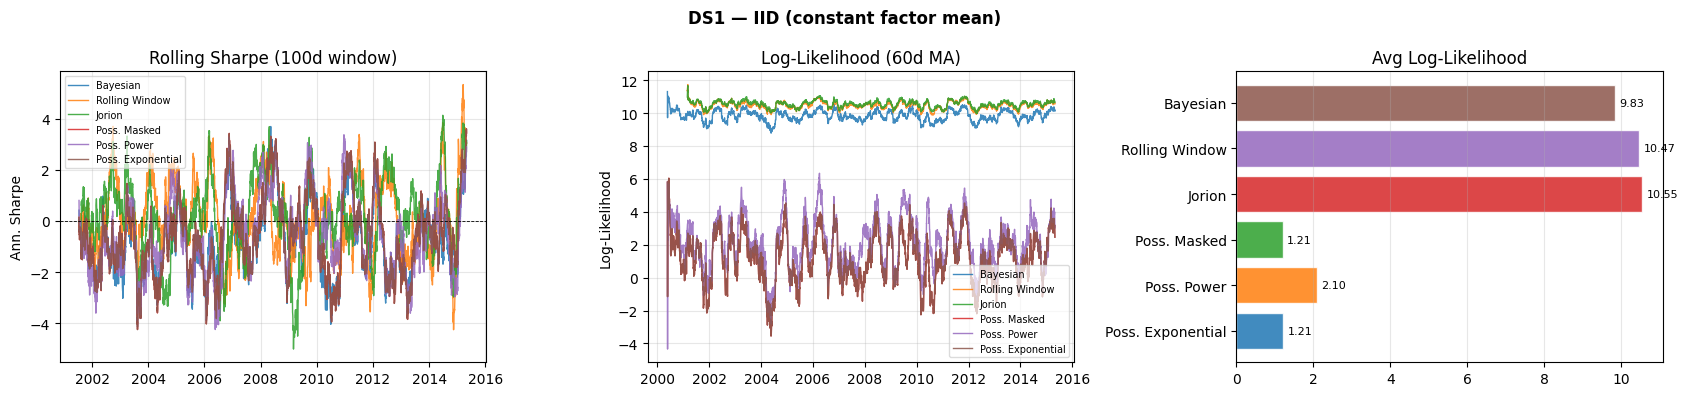

In [38]:
# ── DS1: IID ──────────────────────────────────────────────────────────────────
print("Running DS1 — IID...")
strats_ds1 = run_all_strategies(ds1)
summary_ds1 = plot_dataset_results(ds1, strats_ds1, "DS1 — IID (constant factor mean)")


Running DS2 — Regime shifts...
  Bayesian Averaging...
Processing time step 100 / 4000...
Processing time step 200 / 4000...
Processing time step 300 / 4000...
Processing time step 400 / 4000...
Processing time step 500 / 4000...
Processing time step 600 / 4000...
Processing time step 700 / 4000...
Processing time step 800 / 4000...
Processing time step 900 / 4000...
Processing time step 1000 / 4000...
Processing time step 1100 / 4000...
Processing time step 1200 / 4000...
Processing time step 1300 / 4000...
Processing time step 1400 / 4000...
Processing time step 1500 / 4000...
Processing time step 1600 / 4000...
Processing time step 1700 / 4000...
Processing time step 1800 / 4000...
Processing time step 1900 / 4000...
Processing time step 2000 / 4000...
Processing time step 2100 / 4000...
Processing time step 2200 / 4000...
Processing time step 2300 / 4000...
Processing time step 2400 / 4000...
Processing time step 2500 / 4000...
Processing time step 2600 / 4000...
Processing time st

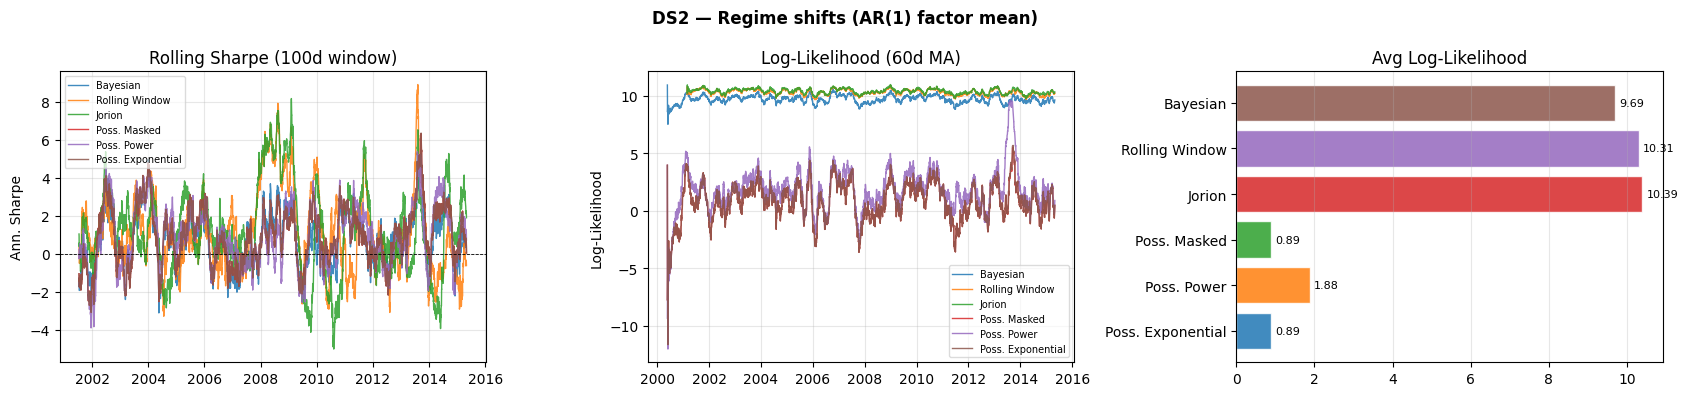

In [39]:
# ── DS2: Regime shifts ────────────────────────────────────────────────────────
print("Running DS2 — Regime shifts...")
strats_ds2 = run_all_strategies(ds2)
summary_ds2 = plot_dataset_results(ds2, strats_ds2, "DS2 — Regime shifts (AR(1) factor mean)")

In [40]:
# ── DS3: Sudden break ─────────────────────────────────────────────────────────
print("Running DS3 — Sudden break...")
strats_ds3 = run_all_strategies(ds3)
summary_ds3 = plot_dataset_results(ds3, strats_ds3, "DS3 — Sudden break (bull → bear at T/2)")


Running DS3 — Sudden break...
  Bayesian Averaging...
Processing time step 100 / 4000...
Processing time step 200 / 4000...
Processing time step 300 / 4000...
Processing time step 400 / 4000...
Processing time step 500 / 4000...
Processing time step 600 / 4000...
Processing time step 700 / 4000...
Processing time step 800 / 4000...
Processing time step 900 / 4000...
Processing time step 1000 / 4000...
Processing time step 1100 / 4000...
Processing time step 1200 / 4000...
Processing time step 1300 / 4000...
Processing time step 1400 / 4000...
Processing time step 1500 / 4000...
Processing time step 1600 / 4000...
Processing time step 1700 / 4000...
Processing time step 1800 / 4000...
Processing time step 1900 / 4000...
Processing time step 2000 / 4000...
Processing time step 2100 / 4000...
Processing time step 2200 / 4000...
Processing time step 2300 / 4000...
Processing time step 2400 / 4000...
Processing time step 2500 / 4000...
Processing time step 2600 / 4000...
Processing time ste

KeyboardInterrupt: 

In [ ]:
# ── DS4: Mean-reverting ───────────────────────────────────────────────────────
print("Running DS4 — Mean-reverting factor...")
strats_ds4 = run_all_strategies(ds4)
summary_ds4 = plot_dataset_results(ds4, strats_ds4, "DS4 — Mean-reverting factor (OU, half-life ~14d)")


In [ ]:
# ── Combined comparison across all datasets ───────────────────────────────────
datasets = {
    "DS1 IID":          summary_ds1,
    "DS2 Regime":       summary_ds2,
    "DS3 Break":        summary_ds3,
    "DS4 Mean-rev.":    summary_ds4,
}

# Sharpe table: rows = strategies, columns = datasets
sharpe_table = pd.concat(
    {label: s["Sharpe (ann.)"] for label, s in datasets.items()}, axis=1
).round(4)

ll_table = pd.concat(
    {label: s["Avg LL"] for label, s in datasets.items()}, axis=1
).round(4)

print("── Annualised Sharpe across datasets ──")
print(sharpe_table.to_string())
print("\n── Average Log-Likelihood across datasets ──")
print(ll_table.to_string())

# Plot: heatmap-style bar charts side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Strategy Comparison across Simulated Datasets", fontsize=13, fontweight="bold")

for ax, table, title, fmt in zip(
    axes,
    [sharpe_table, ll_table],
    ["Annualised Sharpe", "Average Log-Likelihood"],
    ["{:.3f}", "{:.1f}"],
):
    x = np.arange(len(table.columns))
    width = 0.13
    n_strats = len(table.index)
    offsets = np.linspace(-(n_strats - 1) / 2, (n_strats - 1) / 2, n_strats) * width

    for (strat, row), color, offset in zip(table.iterrows(), COLORS, offsets):
        bars = ax.bar(x + offset, row.values, width=width, label=strat,
                      color=color, alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(table.columns, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.legend(fontsize=8, framealpha=0.7, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.savefig("sim_comparison.png", dpi=150)
plt.show()

sharpe_table
